## Figure 9: Changes in SST variability between Control and No-wind Experiments.

**Purpose:** Generate Figure 9 of the paper.

**Description:**
Figure 9 shows, difference in SST standard deviation in [◦C] between the Control and No-wind experiments.

**Inputs:**

**Control experiment –** 
- `sst_MITgcm-RYF_cntl.nc` — Mean SST and SST standard deviation, `MITgcm-RYF` Control experiment

**No-wind experiment –** 
- `sst_MITgcm-RYF_nowind.nc` — Mean SST and SST standard deviation, `MITgcm-RYF` No-wind experiment

In [1]:
import xarray as xr 
import numpy as np 
import pandas as pd
import cartopy.crs as ccrs 
import cartopy.feature as cfeature
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import rcParams
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from shapely.geometry import LineString
from shapely.ops import unary_union
import regionmask
from shapely.geometry import Polygon 
from shapely.ops import unary_union
import warnings
import logging
plt.rcParams['font.size'] = 17

In [2]:
import os
os.chdir('/g/data/er50/sb4233/Scripts/Indonesian-seas-SST-variability_JGR-Oceans/') # set the path to working directory

In [3]:
warnings.filterwarnings('ignore')
mpl.rcParams['text.latex.preamble'] = r'\usepackage[utf8]{inputenc}'
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
logging.getLogger('matplotlib').setLevel(logging.ERROR)
rcParams.update({
    'text.usetex': True,            
    'font.family': 'Palatino Latino',         
    'font.serif': ['Palatino Latino'],  
    'text.latex.preamble': r'\usepackage{amsmath}'  
})

## Datasets

In [4]:
sst_nowind = xr.open_dataset('./data/sst_MITgcm-RYF_nowind.nc')
sst_cntl   = xr.open_dataset('./data/sst_MITgcm-RYF_cntl.nc')

In [5]:
# SST sd difference between Nowind and Control experiments

sst_sd_cntl   = sst_cntl.sd_sst
sst_sd_nowind = sst_nowind.sd_sst

sst_dalta_sd = sst_sd_nowind - sst_sd_cntl

## Figure 9:

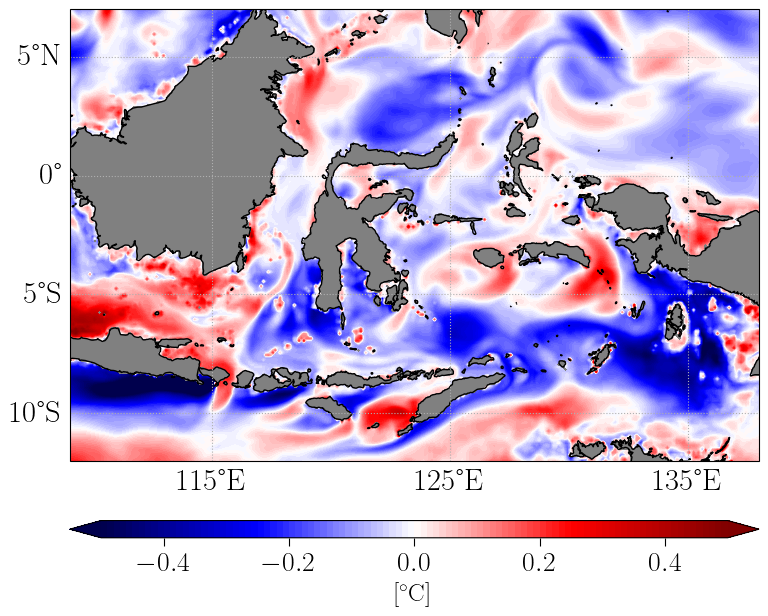

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(8, 7),
                       subplot_kw={'projection': ccrs.PlateCarree()})

var = np.where(sst_dalta_sd != 0, sst_dalta_sd, np.nan)
c = ax.contourf(
    sst_dalta_sd.XC, sst_dalta_sd.YC, var,
    levels=np.linspace(-0.5, 0.5, 101),
    cmap="seismic", extend="both",
    transform=ccrs.PlateCarree()
)
ax.set_title("", loc='left', fontsize=14)
gl = ax.gridlines(draw_labels=True, linestyle=":")
gl.top_labels = False
gl.right_labels = False
gl.xlocator = mticker.FixedLocator([115, 125, 135])
gl.ylocator = mticker.FixedLocator([-10, -5, 0, 5])
gl.xlabel_style = {'size': 22}
gl.ylabel_style = {'size': 22}
ax.coastlines(resolution='10m', lw=1)
ax.add_feature(cfeature.LAND, facecolor="grey")
ax.set_facecolor("grey")
ax.set_extent([109, 138, -12, 7])

cb = fig.colorbar(c, ax=ax, orientation="horizontal",
                  fraction=0.06, pad=0.10, aspect=40,
                  ticks=np.linspace(-0.4, 0.4, 5))
cb.ax.tick_params(size=6, labelsize=20, direction='out')
cb.set_label(r"[$^\circ$C]", fontsize=18)

plt.tight_layout()

#plt.savefig("./figures/fig9.png", dpi=200, bbox_inches="tight", facecolor="white")